## Decision Trees and SVM

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ML models
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import  GridSearchCV


# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [4]:
# Load dataset
df = pd.read_csv("USA_Housing.csv")
print(df.head())

   Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0      79545.458574             5.682861                   7.009188   
1      79248.642455             6.002900                   6.730821   
2      61287.067179             5.865890                   8.512727   
3      63345.240046             7.188236                   5.586729   
4      59982.197226             5.040555                   7.839388   

   Avg. Area Number of Bedrooms  Area Population         Price  \
0                          4.09     23086.800503  1.059034e+06   
1                          3.09     40173.072174  1.505891e+06   
2                          5.13     36882.159400  1.058988e+06   
3                          3.26     34310.242831  1.260617e+06   
4                          4.23     26354.109472  6.309435e+05   

                                             Address  
0  208 Michael Ferry Apt. 674\nLaurabury, NE 3701...  
1  188 Johnson Views Suite 079\nLake Kathleen, CA...  
2  9127 Eli

## PREPROCESSING

In [6]:
# Drop non-useful column if exists
if 'Address' in df.columns:
    df = df.drop('Address', axis=1)

X = df.drop('Price', axis=1)
y = df['Price']

In [7]:
# Convert price into 0 (low) and 1 (high)
y = (y > y.mean()).astype(int)

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Decision Tree

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.835


In [12]:
dt_params = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10]
}

dt_grid = GridSearchCV(DecisionTreeClassifier(), dt_params, cv=5)
dt_grid.fit(X_train, y_train)

best_dt = dt_grid.best_estimator_

y_pred_dt = best_dt.predict(X_test)

print("Best DT Params:", dt_grid.best_params_)
print("DT Accuracy:", accuracy_score(y_test, y_pred_dt))

Best DT Params: {'max_depth': 10, 'min_samples_split': 5}
DT Accuracy: 0.841


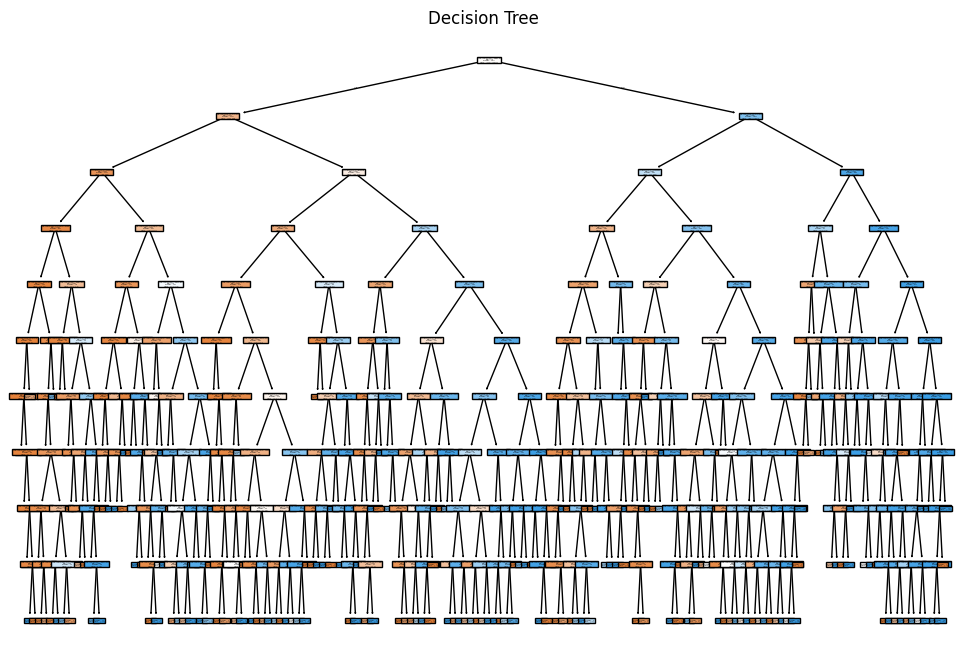

In [16]:
from sklearn.tree import plot_tree
plt.figure(figsize=(12,8))
plot_tree(best_dt, filled=True, feature_names=X.columns)
plt.title("Decision Tree")
plt.show()

This graph shows which features contribute most to the model’s decision-making

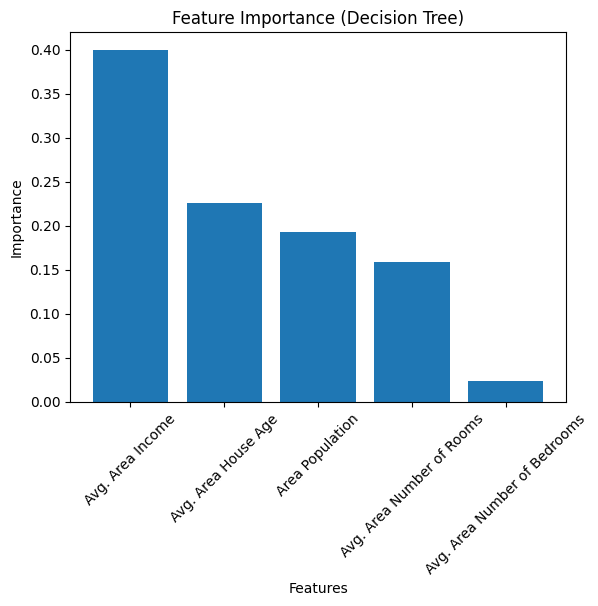

In [17]:
import pandas as pd

importances = best_dt.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure()
plt.bar(feat_df['Feature'], feat_df['Importance'])
plt.xticks(rotation=45)
plt.title("Feature Importance (Decision Tree)")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [18]:
from sklearn.metrics import accuracy_score

# Prediction already done earlier
y_pred_dt = best_dt.predict(X_test)

dt_acc = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.841
